In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
%matplotlib tk

plt.close('all')

In [4]:
## Compare CRLBs for different connectivities and amlitudes

df = pd.read_csv("crlb.csv", index_col=None).drop('Unnamed: 0', axis=1)
df['phase2'] = df.phase2.replace({np.pi: 'out-of-phase', 0: 'in-phase'})

g = sns.FacetGrid(df, hue='phase2', col='theta', row='amplitude', height=3, aspect=1.5)
g.map(sns.kdeplot, 'log_crlb')
g.add_legend()
plt.show()

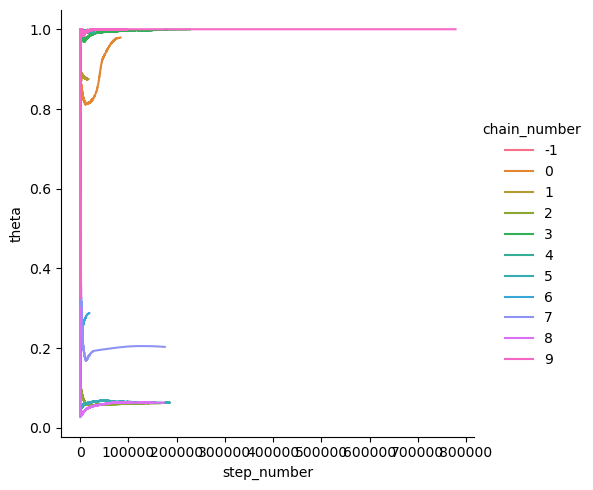

In [60]:
seasonal = pd.read_csv(f"res/debug_seasonal_yairdock.csv").assign(seasonal=True)
no_seasonal = pd.read_csv(f"res/debug_not_seasonal_yairdock.csv").assign(seasonal=False)
df = pd.concat([seasonal, no_seasonal])
df = df[['seasonal', 'chain_number', 'step_number', 'fun', 'theta']] # 'beta0', 'eps', 'omega', 
df = df.sort_values(["seasonal", "chain_number", "step_number"]).query("chain_number > 0")#.assign(chain_number=df.chain_number.astype(str))# + 12 * df.seasonal)



truths = df.query("chain_number == -1").drop(['fun', 'chain_number', "step_number"],axis=1)
optimals = df.query("step_number < 0").drop(['step_number'], axis=1).set_index("chain_number", drop=True)
df.head()


sns.relplot(data=dd.query("not seasonal"), hue='chain_number', x='step_number', y='theta', kind='line')

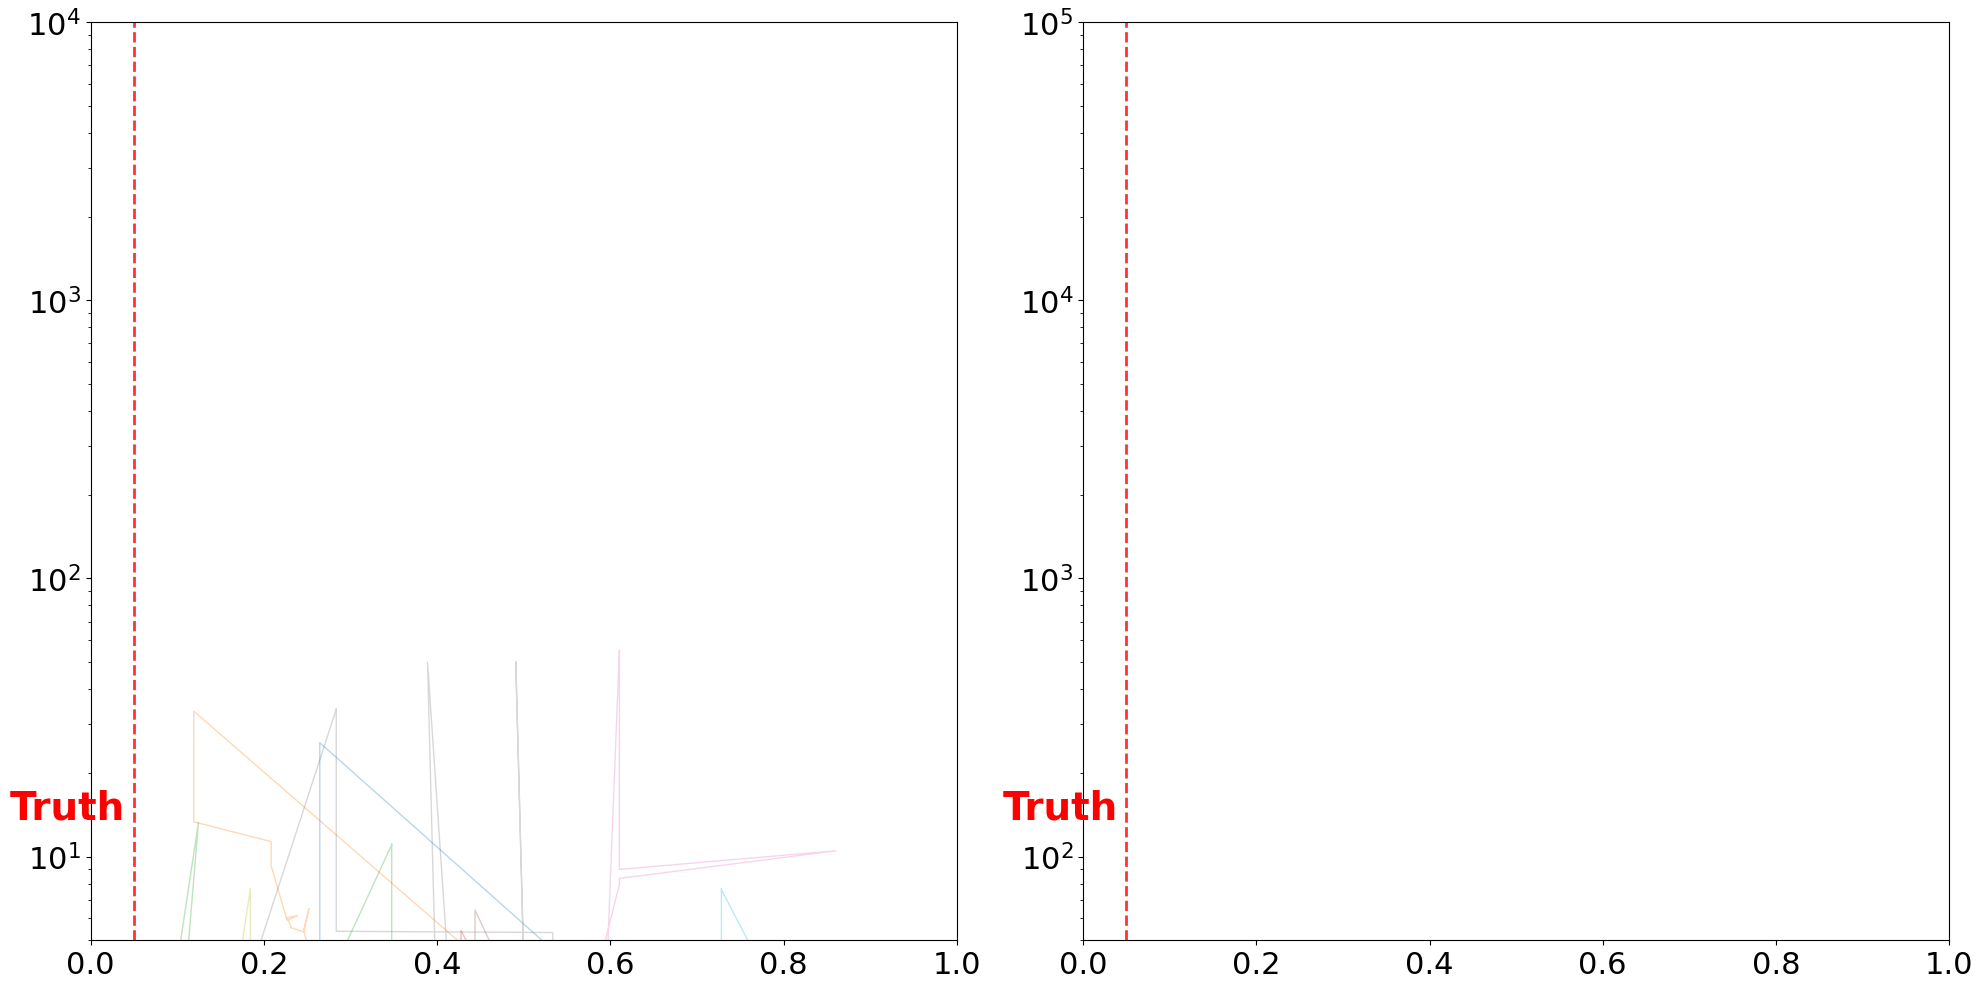

In [25]:
fs = 33
parameter = "theta"
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for i, seasonal in enumerate([True, False]):
    ax = axes[i]
    
    # Get data for this seasonal setting
    dd = df.query("seasonal == @seasonal")
    opt = optimals.query("seasonal == @seasonal")
    true_val = truths.query("seasonal == @seasonal")[parameter].iloc[0]

    ## Truth
    ax.axvline(x=true_val, color='red', linestyle='--', 
               linewidth=2, alpha=0.8)
    ax.text(true_val-0.01, 150*10**(-int(seasonal)), 'Truth', rotation=0,
            verticalalignment='center', horizontalalignment='right', 
            color='red', fontsize=fs-5, fontweight='bold')           

    
    for chain, data in dd.groupby("chain_number"):
        line, = ax.plot(data[parameter], data['fun'], alpha=0.3, linewidth=1)    
        
        chain_opt = opt.loc[opt.index == chain]
        if len(chain_opt) > 0:
            oo = chain_opt[[parameter, 'fun']].iloc[0].values
            ax.scatter(*oo, marker='*', s=60, alpha=1, color=line.get_color())

    if i == 0:
        
        ax.set_ylim([5, 1e4])
    else:
        ax.set_ylim([50, 1e5])
        #ax.set_xlabel("Connectivity", fontsize=fs)

    
    ax.tick_params(axis='x', labelsize=22)
    ax.tick_params(axis='y', labelsize=22)

    #ax.set_ylabel('Objective', fontsize=fs)
    ax.set_xlim([0, 1])
    ax.set_yscale('log')
    #flag = "With" if seasonal else "Without"
    #ax.set_title(f"{flag} Seasonal Driver", fontsize=fs)
    
plt.tight_layout()
plt.savefig("pix/poster.jpg", dpi=350)
plt.show()

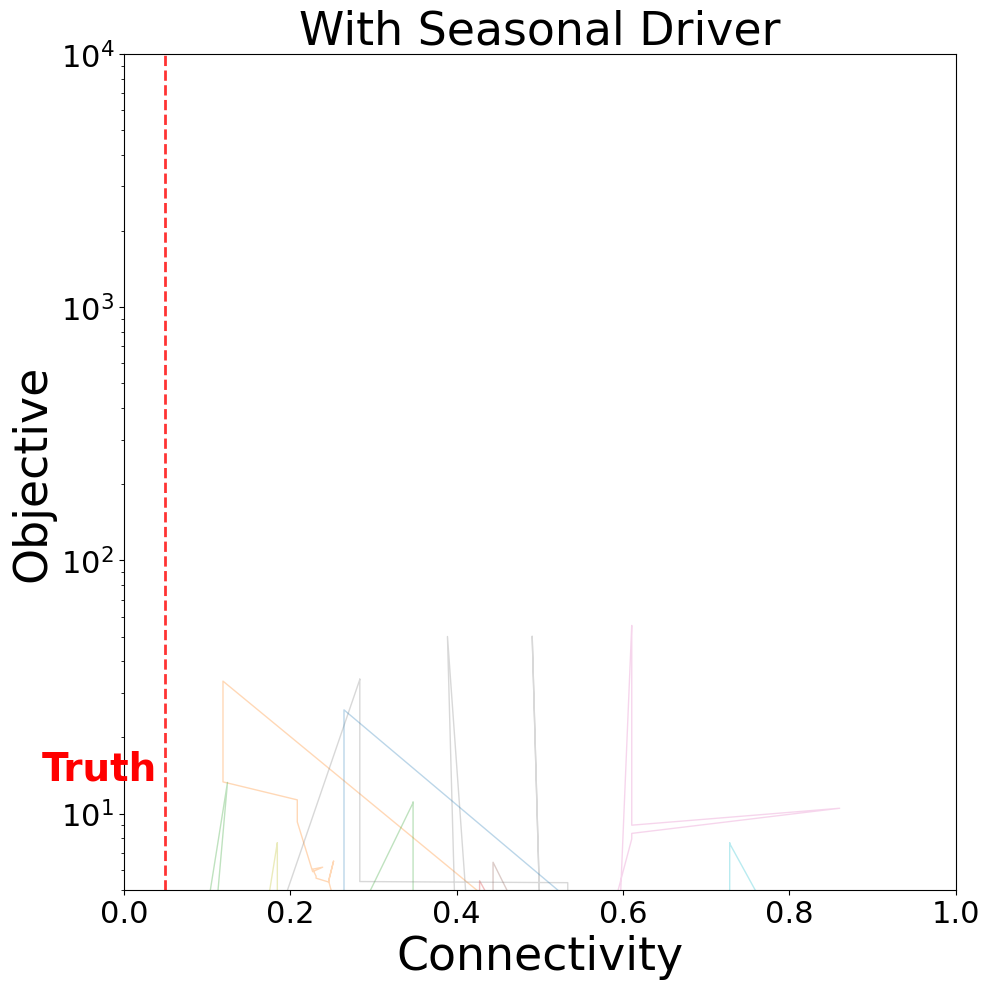

In [26]:
fs = 33
parameter = "theta"
seasonal = True
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

dd = df.query("seasonal== @seasonal")
opt = optimals.query("seasonal == @seasonal")
true_val = truths.query("seasonal == @seasonal")[parameter].iloc[0]

## Truth
ax.axvline(x=true_val, color='red', linestyle='--', 
           linewidth=2, alpha=0.8)
ax.text(true_val-0.01, 150*10**(-int(seasonal)), 'Truth', rotation=0,
        verticalalignment='center', horizontalalignment='right', 
        color='red', fontsize=fs-5, fontweight='bold')           


for chain, data in dd.groupby("chain_number"):
    line, = ax.plot(data[parameter], data['fun'], alpha=0.3, linewidth=1)    
    
    chain_opt = opt.loc[opt.index == chain]
    if len(chain_opt) > 0:
        oo = chain_opt[[parameter, 'fun']].iloc[0].values
        ax.scatter(*oo, marker='*', s=60, alpha=1, color=line.get_color())

if seasonal:
    ax.set_ylim([5, 1e4])    
else:
    ax.set_ylim([50, 1e5])
ax.set_xlabel("Connectivity", fontsize=fs)


ax.tick_params(axis='x', labelsize=22)
ax.tick_params(axis='y', labelsize=22)

ax.set_ylabel('Objective', fontsize=fs)
ax.set_xlim([0, 1])
ax.set_yscale('log')
flag = "With" if seasonal else "Without"
ax.set_title(f"{flag} Seasonal Driver", fontsize=fs)

plt.tight_layout()
plt.savefig("pix/poster.jpg", dpi=350)
plt.show()

In [50]:
df

,seasonal,chain_number,step_number,fun,theta
0,False,-1,0,NaN,0.050000
15001,False,0,-1,0.125615,0.452799
1,False,0,0,10.424900,0.651745
2,False,0,1,10.385016,0.651745
3,False,0,2,10.369263,0.651745
...,...,...,...,...,...
10005,True,9,995,0.287120,0.969369
10006,True,9,996,0.286854,0.965987
10007,True,9,997,0.286781,0.968515
10008,True,9,998,0.287454,0.970496


ValueError: cannot reindex on an axis with duplicate labels

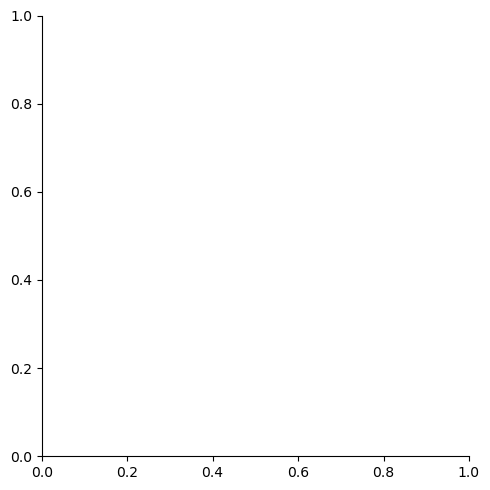

In [47]:
sns.relplot(data=df, hue='chain_number', x='step_number', y='fun')

,seasonal,chain_number,step_number,fun,theta
0,False,-1,0,NaN,0.050000
5001,False,0,-1,0.122219,0.174099
1,False,0,0,13.480742,0.261588
2,False,0,1,13.325962,0.261588
3,False,0,2,13.278211,0.261588
...,...,...,...,...,...
10005,True,9,995,0.287120,0.969369
10006,True,9,996,0.286854,0.965987
10007,True,9,997,0.286781,0.968515
10008,True,9,998,0.287454,0.970496


In [21]:
df.groupby(["chain_number", "seasonal"]).size().median()

42288.5